# МКР 2. Варіант 4

У роботі розглядаються два марківські процеси: дискретний ланцюг Маркова та марківський випадковий процес з неперервним часом. Обчислення виконуються з точністю до `10^-4`, а стабілізація в першому завданні перевіряється за критерієм `eps = 10^-3`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## Завдання 1

Для ланцюга Маркова задано розмічений граф станів системи та початковий стан `S2`. За графом будується матриця перехідних ймовірностей `P`. Оскільки петлі на графі не показані, ймовірності залишатися у тому самому стані записані на діагоналі як залишок до суми рядка 1.

Початковий вектор:

```text
p(0) = [0, 1, 0, 0, 0]
```

Наступні вектори ймовірностей обчислюються за формулою:

```text
p(k+1) = p(k) · P
```

Обчислення триває, поки максимальна зміна ймовірностей не стане меншою за `eps = 10^-3`.

In [2]:
# Матриця перехідних ймовірностей для варіанта 4
P = np.array([
    [0.3, 0.6, 0.0, 0.1, 0.0],
    [0.2, 0.4, 0.3, 0.0, 0.1],
    [0.0, 0.0, 0.4, 0.4, 0.2],
    [0.2, 0.0, 0.2, 0.1, 0.5],
    [0.4, 0.0, 0.3, 0.2, 0.1],
], dtype=float)

print("Суми рядків P:", P.sum(axis=1))

# Початковий вектор: система спочатку знаходиться у стані S2
p0 = np.array([0.0, 1.0, 0.0, 0.0, 0.0])

eps = 1e-3
states = [p0]
k = 0

while True:
    p_next = states[-1] @ P
    diff = np.max(np.abs(p_next - states[-1]))
    states.append(p_next)
    k += 1

    if diff < eps:
        break

df_task1 = pd.DataFrame(states, columns=["S1", "S2", "S3", "S4", "S5"])
df_task1.insert(0, "Крок", range(k + 1))

print("Кількість кроків до стабілізації:", k)
print("Фінальні ймовірності:", np.round(states[-1], 4))

df_task1.round(4)

Суми рядків P: [1. 1. 1. 1. 1.]
Кількість кроків до стабілізації: 8
Фінальні ймовірності: [0.206  0.2055 0.2457 0.1705 0.1724]


,Крок,S1,S2,S3,S4,S5
0,0,0.0000,1.0000,0.0000,0.0000,0.0000
1,1,0.2000,0.4000,0.3000,0.0000,0.1000
2,2,0.1800,0.2800,0.2700,0.1600,0.1100
3,3,0.1860,0.2200,0.2570,0.1640,0.1730
4,4,0.2018,0.1996,0.2535,0.1724,0.1727
5,5,0.2040,0.2009,0.2476,0.1734,0.1741
6,6,0.2057,0.2028,0.2462,0.1716,0.1737
7,7,0.2061,0.2045,0.2457,0.1710,0.1727
8,8,0.2060,0.2055,0.2457,0.1705,0.1724


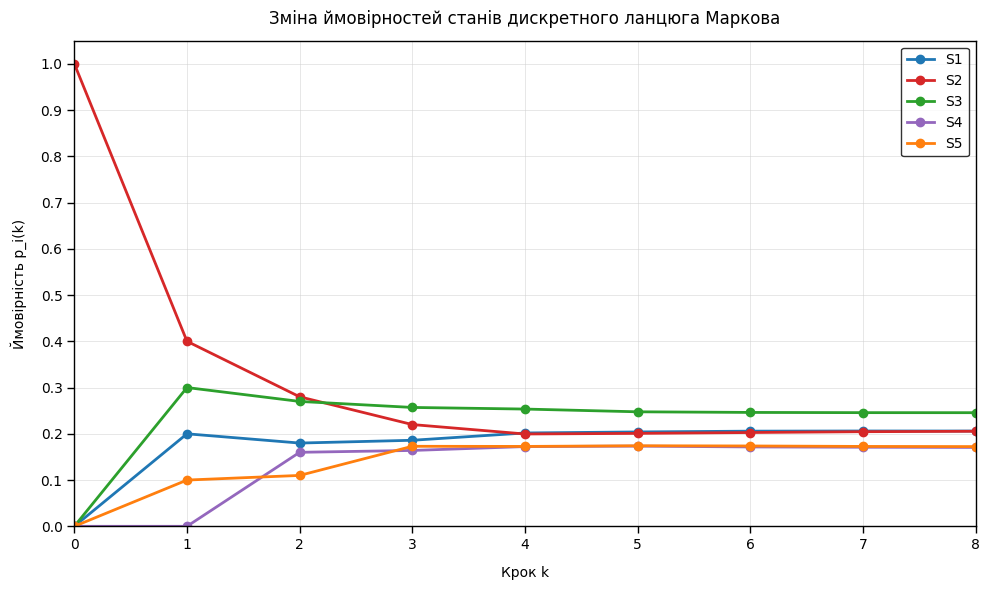

In [3]:
def plot_discrete_probabilities(df, final_probabilities=None):
    fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
    ax.set_facecolor("white")

    states_names = ["S1", "S2", "S3", "S4", "S5"]
    colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e"]
    final_colors = ["#6baed6", "#fb6a4a", "#74c476", "#b39ddb", "#ffbb78"]

    for i, state in enumerate(states_names):
        ax.plot(
            df["\u041a\u0440\u043e\u043a"],
            df[state],
            marker="o",
            markersize=6,
            linewidth=2,
            color=colors[i],
            label=state,
        )

        if final_probabilities is not None:
            ax.axhline(
                y=final_probabilities[state],
                color=final_colors[i],
                linestyle="--",
                linewidth=1.6,
                alpha=0.85,
                label=f"{state} \u0441\u0442\u0430\u0446. = {final_probabilities[state]:.4f}",
            )

    ax.set_title("\u0417\u043c\u0456\u043d\u0430 \u0439\u043c\u043e\u0432\u0456\u0440\u043d\u043e\u0441\u0442\u0435\u0439 \u0441\u0442\u0430\u043d\u0456\u0432 \u0434\u0438\u0441\u043a\u0440\u0435\u0442\u043d\u043e\u0433\u043e \u043b\u0430\u043d\u0446\u044e\u0433\u0430 \u041c\u0430\u0440\u043a\u043e\u0432\u0430", color="black", pad=12)
    ax.set_xlabel("\u041a\u0440\u043e\u043a k", color="black", labelpad=10)
    ax.set_ylabel("\u0419\u043c\u043e\u0432\u0456\u0440\u043d\u0456\u0441\u0442\u044c p_i(k)", color="black", labelpad=10)

    ax.set_xlim(df["\u041a\u0440\u043e\u043a"].min(), df["\u041a\u0440\u043e\u043a"].max())
    ax.set_ylim(0, 1.05)
    ax.set_xticks(df["\u041a\u0440\u043e\u043a"])
    y_ticks = np.round(np.arange(0.0, 1.01, 0.1), 1)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{value:.1f}" for value in y_ticks])

    ax.tick_params(axis="both", which="major", colors="black", labelsize=10, length=5, width=1)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

    ax.grid(True, color="#cfcfcf", alpha=0.7)
    ax.legend(facecolor="white", edgecolor="black", labelcolor="black")
    plt.tight_layout()
    plt.show()


plot_discrete_probabilities(df_task1)

### Стаціонарні ймовірності

Стаціонарний вектор `π` знаходиться з системи:

```text
πP = π
π1 + π2 + π3 + π4 + π5 = 1
```

Для обчислення використовується система `(P.T - I)π = 0`, де останнє рівняння замінюється умовою нормування.

Стаціонарні ймовірності:
p1 = 0.2059
p2 = 0.2059
p3 = 0.2458
p4 = 0.1704
p5 = 0.1721

Різниця: [0.00013832 0.00039918 0.00012656 0.00017528 0.00021213]


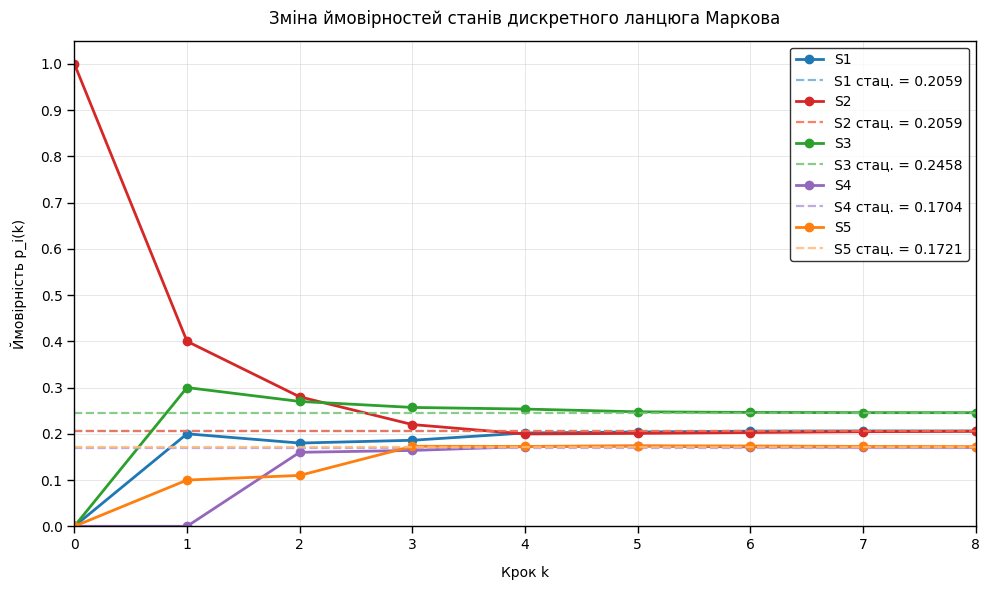

In [4]:
n = P.shape[0]

A_stationary = P.T - np.eye(n)
A_stationary[-1] = np.ones(n)

b = np.zeros(n)
b[-1] = 1

pi = np.linalg.solve(A_stationary, b)

print("Стаціонарні ймовірності:")
for i, value in enumerate(pi, start=1):
    print(f"p{i} = {value:.4f}")

print("\nРізниця:", np.abs(states[-1] - pi))

final_probabilities_task1 = {f"S{i}": value for i, value in enumerate(pi, start=1)}
plot_discrete_probabilities(df_task1, final_probabilities_task1)

### Висновок до завдання 1

Ітераційно отримані ймовірності практично збігаються зі стаціонарними ймовірностями, знайденими з системи рівнянь. Отже, для заданого ланцюга існує усталений режим. Найбільш імовірним у стаціонарному режимі є стан S3, оскільки його стаціонарна ймовірність є найбільшою.

## Завдання 2

Задано матрицю інтенсивностей переходів:

```text
Λ = [[0, 3, 1, 1],
     [2, 0, 1, 2],
     [2, 1, 0, 3],
     [0, 3, 2, 0]]
```

Початковий вектор станів:

```text
S = [0, 0, 1, 0]
```

Для ймовірностей станів використовується система Колмогорова `dp/dt = A · p`, де діагональні елементи матриці `A` дорівнюють від’ємним сумам інтенсивностей виходу зі станів, а недіагональні елементи задають надходження ймовірностей з інших станів.

In [5]:
Lambda = np.array([
    [0, 3, 1, 1],
    [2, 0, 1, 2],
    [2, 1, 0, 3],
    [0, 3, 2, 0],
], dtype=float)

A = Lambda.T.copy()
np.fill_diagonal(A, -Lambda.sum(axis=1))

print("Матриця A для системи dp/dt = A · p:")
print(A)
print("Суми стовпців A:", A.sum(axis=0))

Матриця A для системи dp/dt = A · p:
[[-5.  2.  2.  0.]
 [ 3. -5.  1.  3.]
 [ 1.  1. -6.  2.]
 [ 1.  2.  3. -5.]]
Суми стовпців A: [0. 0. 0. 0.]


Система диференціальних рівнянь Колмогорова має вигляд:

```text
dp1/dt = -5p1 + 2p2 + 2p3
dp2/dt = 3p1 - 5p2 + p3 + 3p4
dp3/dt = p1 + p2 - 6p3 + 2p4
dp4/dt = p1 + 2p2 + 3p3 - 5p4
```

In [6]:
def kolmogorov_system(t, p):
    return A @ p


test_p = np.array([0.25, 0.25, 0.25, 0.25])
print("Сума похідних:", np.sum(kolmogorov_system(0, test_p)))


def rk4(f, x0, y0, xn, h):
    steps = int((xn - x0) / h)
    xs = x0 + h * np.arange(steps + 1, dtype=float)

    y = np.asarray(y0, dtype=float)
    ys = np.empty((steps + 1,) + y.shape, dtype=float)
    ys[0] = y

    for i in range(steps):
        x = xs[i]
        k1 = h * np.asarray(f(x, y), dtype=float)
        k2 = h * np.asarray(f(x + h / 2.0, y + k1 / 2.0), dtype=float)
        k3 = h * np.asarray(f(x + h / 2.0, y + k2 / 2.0), dtype=float)
        k4 = h * np.asarray(f(x + h, y + k3), dtype=float)
        y = y + (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0
        ys[i + 1] = y

    return xs, ys


def estimate_t_critical(ts, probs, eps=1e-4, window=30):
    if len(ts) <= window:
        return ts[-1]

    deltas = np.max(np.abs(np.diff(probs, axis=0)), axis=1)
    calm = deltas < eps

    streak = 0
    for i, ok in enumerate(calm):
        if ok:
            streak += 1
            if streak >= window:
                return ts[i - window + 2]
        else:
            streak = 0
    return ts[-1]

Сума похідних: 0.0


In [7]:
t0 = 0.0
tn = 5.0
h = 0.01
p0_continuous = np.array([0.0, 0.0, 1.0, 0.0], dtype=float)

ts, probs = rk4(kolmogorov_system, t0, p0_continuous, tn, h)

print("Розв'язання системи Колмогорова методом Рунге-Кутта 4")
print(f"Сума ймовірностей на старті: {np.sum(probs[0]):.6f}")
print(f"Сума ймовірностей в кінці:  {np.sum(probs[-1]):.6f}")

df_task2 = pd.DataFrame(probs, columns=["p1", "p2", "p3", "p4"])
df_task2.insert(0, "t", ts)

sample_indices = list(range(0, len(df_task2), 50))
if sample_indices[-1] != len(df_task2) - 1:
    sample_indices.append(len(df_task2) - 1)

df_task2.iloc[sample_indices].round(4)

Розв'язання системи Колмогорова методом Рунге-Кутта 4
Сума ймовірностей на старті: 1.000000
Сума ймовірностей в кінці:  1.000000


,t,p1,p2,p3,p4
0,0.0,0.0000,0.0000,1.0000,0.0000
50,0.5,0.2002,0.3045,0.2072,0.2881
100,1.0,0.2044,0.3281,0.1842,0.2833
150,1.5,0.2049,0.3291,0.1833,0.2827
200,2.0,0.2050,0.3292,0.1832,0.2826
250,2.5,0.2050,0.3292,0.1832,0.2826
300,3.0,0.2050,0.3292,0.1832,0.2826
350,3.5,0.2050,0.3292,0.1832,0.2826
400,4.0,0.2050,0.3292,0.1832,0.2826
450,4.5,0.2050,0.3292,0.1832,0.2826


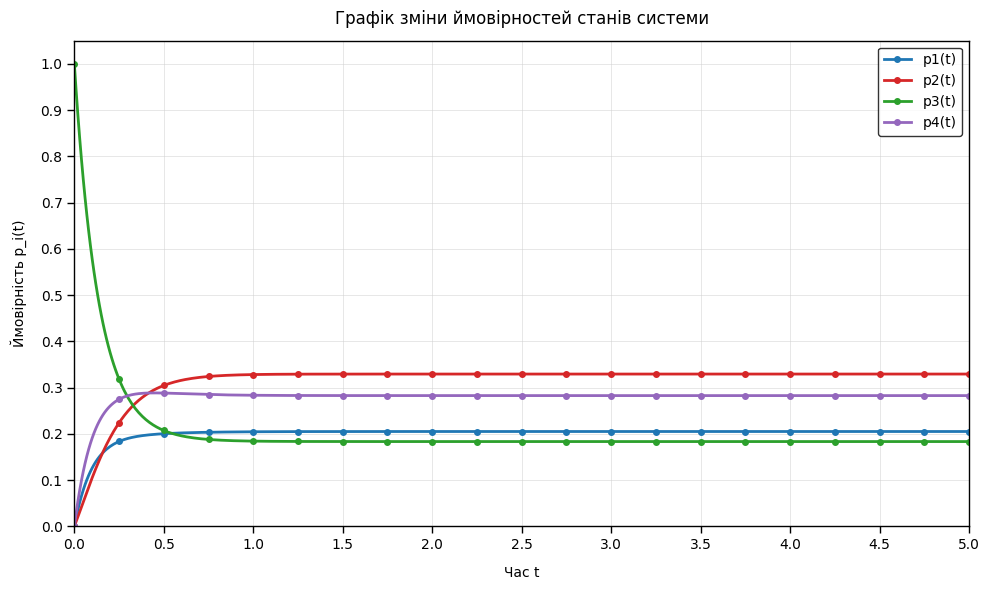

In [8]:
def plot_continuous_probabilities(ts, probs, t_critical=None, p_reference=None):
    fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
    ax.set_facecolor("white")

    labels = ["p1(t)", "p2(t)", "p3(t)", "p4(t)"]
    colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]
    final_colors = ["#6baed6", "#fb6a4a", "#74c476", "#b39ddb"]

    for i, label in enumerate(labels):
        ax.plot(
            ts,
            probs[:, i],
            color=colors[i],
            linewidth=2,
            marker="o",
            markersize=4,
            markevery=max(len(ts) // 20, 1),
            label=label,
        )

        if p_reference is not None:
            ax.axhline(
                y=p_reference[i],
                color=final_colors[i],
                linestyle="--",
                linewidth=2,
                alpha=0.85,
                label=f"p{i + 1} \u0441\u0442\u0430\u0446. = {p_reference[i]:.4f}",
            )

    if t_critical is not None:
        ax.axvline(t_critical, color="black", linestyle="--", linewidth=1.4, label=f"t\u043a\u0440 \u2248 {t_critical:.2f}")

    ax.set_title("\u0413\u0440\u0430\u0444\u0456\u043a \u0437\u043c\u0456\u043d\u0438 \u0439\u043c\u043e\u0432\u0456\u0440\u043d\u043e\u0441\u0442\u0435\u0439 \u0441\u0442\u0430\u043d\u0456\u0432 \u0441\u0438\u0441\u0442\u0435\u043c\u0438", color="black", pad=12)
    ax.set_xlabel("\u0427\u0430\u0441 t", color="black", labelpad=10)
    ax.set_ylabel("\u0419\u043c\u043e\u0432\u0456\u0440\u043d\u0456\u0441\u0442\u044c p_i(t)", color="black", labelpad=10)

    ax.set_xlim(ts.min(), ts.max())
    ax.set_ylim(0, 1.05)
    ax.set_xticks(np.round(np.arange(ts.min(), ts.max() + 0.001, 0.5), 2))
    y_ticks = np.round(np.arange(0.0, 1.01, 0.1), 1)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{value:.1f}" for value in y_ticks])

    ax.tick_params(axis="both", which="major", colors="black", labelsize=10, length=5, width=1)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

    ax.grid(True, color="#cfcfcf", alpha=0.7)
    ax.legend(facecolor="white", edgecolor="black", labelcolor="black")
    plt.tight_layout()
    plt.show()


plot_continuous_probabilities(ts, probs)

### Аналітичні фінальні ймовірності

Стаціонарний режим визначається системою:

```text
A · p = 0
p1 + p2 + p3 + p4 = 1
```

In [9]:
n = A.shape[0]

A_stat = A.copy()
A_stat[-1] = np.ones(n)

b = np.zeros(n)
b[-1] = 1

p_stat = np.linalg.solve(A_stat, b)
p_final_numeric = probs[-1]
t_critical = estimate_t_critical(ts, probs)

print("Аналітичні фінальні ймовірності:")
for i, value in enumerate(p_stat, start=1):
    print(f"p{i} = {value:.4f}")

print("\nЧисельні фінальні ймовірності:")
for i, value in enumerate(p_final_numeric, start=1):
    print(f"p{i} = {value:.4f}")

print("\nРізниця між чисельним та аналітичним результатом:")
print(np.abs(p_final_numeric - p_stat))

print(f"\ntкр ≈ {t_critical:.2f}")

Аналітичні фінальні ймовірності:
p1 = 0.2050
p2 = 0.3292
p3 = 0.1832
p4 = 0.2826

Чисельні фінальні ймовірності:
p1 = 0.2050
p2 = 0.3292
p3 = 0.1832
p4 = 0.2826

Різниця між чисельним та аналітичним результатом:
[6.45150600e-13 2.37032616e-13 3.22852856e-13 5.58719737e-13]

tкр ≈ 0.95


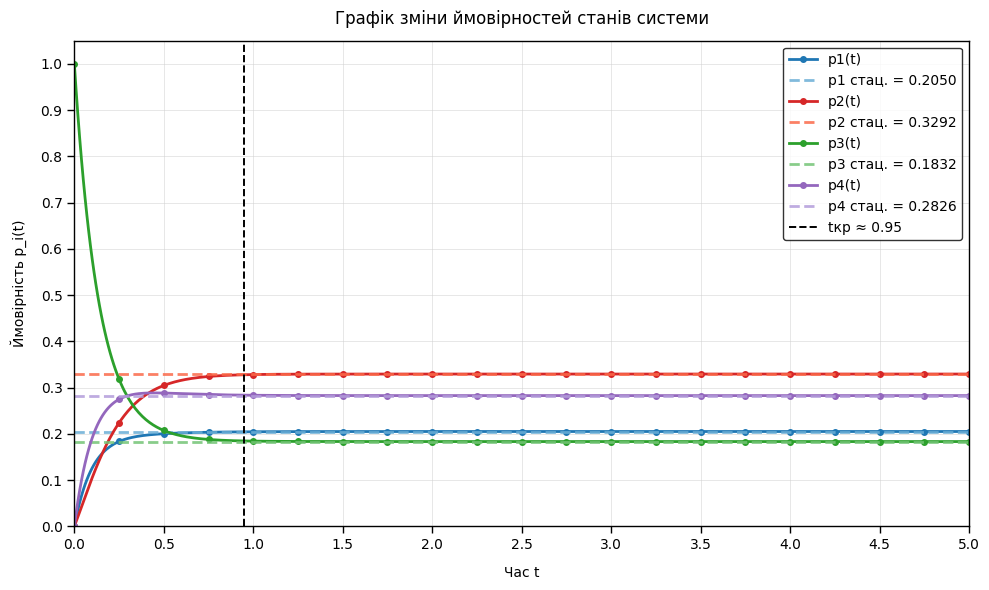

In [10]:
plot_continuous_probabilities(ts, probs, t_critical, p_stat)

### Висновок до завдання 2

Оскільки чисельні фінальні ймовірності збігаються з аналітичними з точністю до `10^-4`, результати можна вважати коректними. Критичний час стабілізації становить приблизно `tкр ≈ 0.95`. Найбільш імовірним у стаціонарному режимі є стан `S2`.